# Análise dos dados

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

In [4]:
classifications_df = pd.read_csv("../data/raw/classifications.csv")
classifications_df

,image_id,image_filename,image_doi,cell_id,bethesda_system,nucleus_x,nucleus_y
0,400,9ae8a4edde40219bad6303cebc672ee4.png,10.6084/m9.figshare.12230906,1,SCC,792,462
1,400,9ae8a4edde40219bad6303cebc672ee4.png,10.6084/m9.figshare.12230906,2,SCC,601,678
2,400,9ae8a4edde40219bad6303cebc672ee4.png,10.6084/m9.figshare.12230906,3,SCC,363,467
3,400,9ae8a4edde40219bad6303cebc672ee4.png,10.6084/m9.figshare.12230906,4,SCC,599,437
4,400,9ae8a4edde40219bad6303cebc672ee4.png,10.6084/m9.figshare.12230906,5,Negative for intraepithelial lesion,1186,450
...,...,...,...,...,...,...,...
11529,1,be340ee72689dfe3f8dc9c24de6127f4.png,10.6084/m9.figshare.12229511,11530,LSIL,618,407
11530,1,be340ee72689dfe3f8dc9c24de6127f4.png,10.6084/m9.figshare.12229511,11531,LSIL,607,374
11531,1,be340ee72689dfe3f8dc9c24de6127f4.png,10.6084/m9.figshare.12229511,11532,LSIL,707,251
11532,1,be340ee72689dfe3f8dc9c24de6127f4.png,10.6084/m9.figshare.12229511,11533,LSIL,579,246


In [30]:
def print_image(image_path):
    fig, ax = plt.subplots(figsize=(5, 5))
    image = Image.open(image_path)
    
    ax.imshow(image)
    ax.axis('off')

def print_cell(image_path, x, y, width, height):
    fig, ax = plt.subplots(figsize=(5, 5))
    image = Image.open(image_path)
    
    cell = image.crop((x, y, x + width, y + height))
    ax.imshow(cell)
    
    # Marcar o centro da célula
    ax.plot(width / 2, height / 2, marker='o', markersize=5, color='red')
    
    # Faz uma seta com um texto escrito "Centro da célula"
    ax.annotate('Centro da célula', xy=(width / 2, height / 2), xytext=(width / 2 + 50, height / 2 + 50),
                arrowprops=dict(arrowstyle='->', color='blue'))
    
    ax.axis('off')

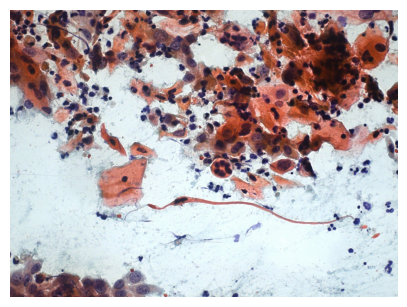

In [18]:
image_folder = Path("../data/raw/images/")
image_path = image_folder / classifications_df["image_filename"][0]

print_image(image_path)

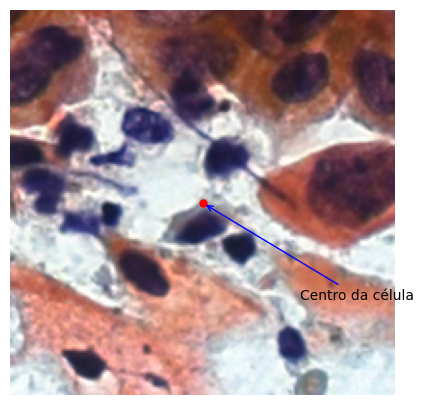

In [31]:
cell_coord = (classifications_df["nucleus_x"][0], classifications_df["nucleus_y"][0])
width, height = (200, 200)

print_cell(image_path, cell_coord[0], cell_coord[1], width, height)